In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.titlesize'] = 13   
plt.rcParams['axes.titlesize'] = 11     



In [32]:
df = pd.read_csv("df_bank.csv", sep = ";", encoding= "ISO-8859-1")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


Verificando se há valores nulos

In [3]:
df.isnull().any(axis=1).sum()

np.int64(0)

## Distribuição da idade dos clientes

O primeiro passo da análise exploratória consiste em compreender a **distribuição da idade dos clientes** presentes no dataset.

A análise de distribuição permite identificar características importantes dos dados, como **concentração de valores, dispersão, assimetria e presença de possíveis outliers**.

Para isso, inicialmente são calculadas algumas **estatísticas descritivas**, como os quartis da distribuição. Essas métricas auxiliam na interpretação dos gráficos e ajudam a compreender como os valores de idade estão distribuídos entre os clientes.

In [4]:
q1_age = df['age'].quantile(0.25)
q2_age = df['age'].quantile(0.50)
q3_age = df['age'].quantile(0.75)

iqr_age = q3_age - q1_age
lim_sup_age = q3_age  + 1.5 * iqr_age
lim_inf_age = q1_age  - 1.5 * iqr_age

Para visualizar a distribuição da idade dos clientes, foram utilizados três tipos de gráficos:

- **Histograma**, que mostra a frequência de observações em diferentes intervalos de idade.
- **Boxplot**, que resume a distribuição utilizando medidas estatísticas como mediana e quartis, além de indicar possíveis outliers.
- **Gráfico de violino**, que combina características do boxplot com a estimativa da densidade da distribuição.

A combinação dessas três visualizações permite uma compreensão mais completa da distribuição dos dados.

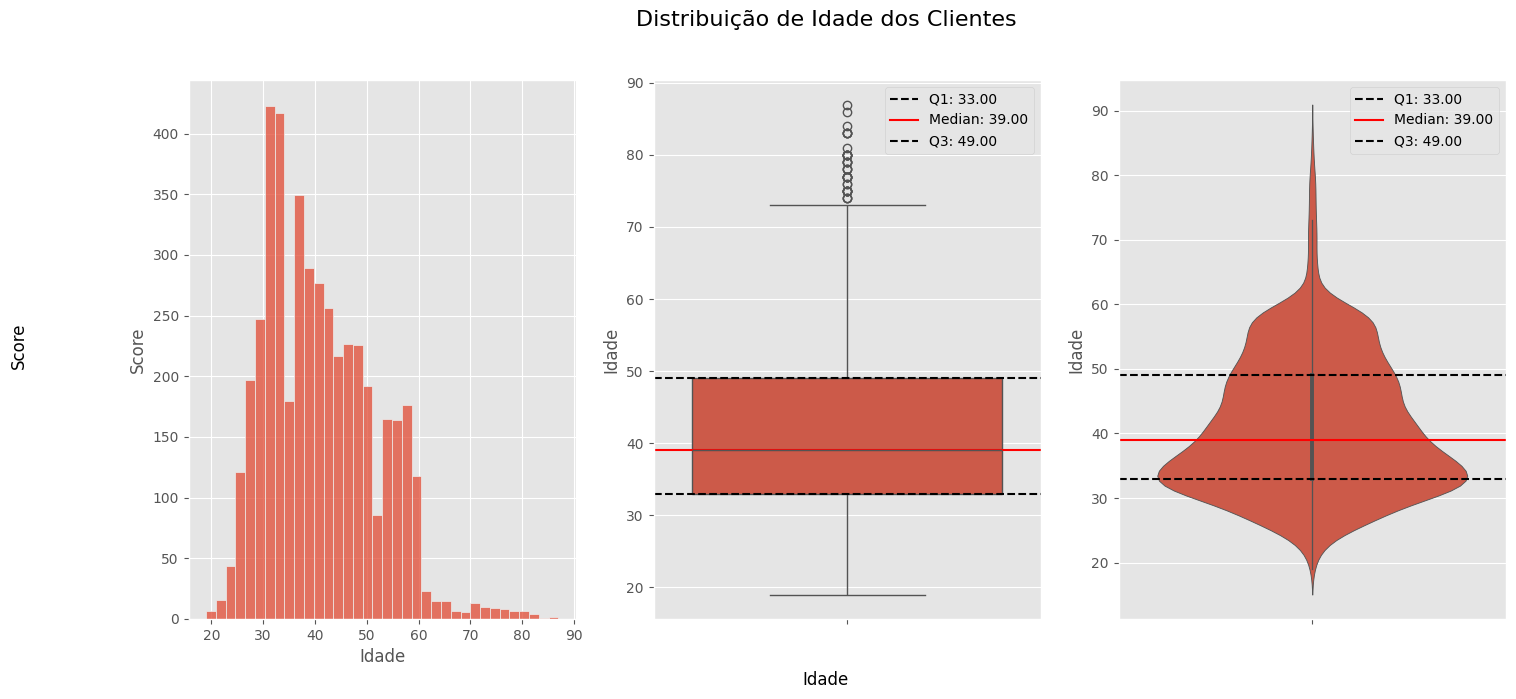

In [5]:
fig, axes = plt.subplots(1, 3, figsize = (17, 7))

# Definindo o titulo 
fig.suptitle("Distribuição de Idade dos Clientes", fontsize = 16)
fig.supxlabel('Idade')
fig.supylabel('Score')

# Gráfico 1 - Histograma
axes[0] = sns.histplot(data = df, x = df['age'], ax = axes[0])
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Score')

# Gráfico 2 - Boxplot
axes[1] = sns.boxplot(data = df, y = df['age'], ax = axes[1])
axes[1].set_ylabel('Idade')
axes[1].axhline(q1_age, color = 'black', linestyle = '--', label = f'Q1: {q1_age:.2f}')
axes[1].axhline(q2_age, color = 'red', linestyle = '-', label = f'Median: {q2_age:.2f}')
axes[1].axhline(q3_age, color = 'black', linestyle = '--', label = f'Q3: {q3_age:.2f}')
axes[1].legend()
# Gráfico 3 - Violin
axes[2] = sns.violinplot(data = df, y = df['age'])
axes[2].set_ylabel('Idade')
axes[2].axhline(q1_age, color = 'black', linestyle = '--', label = f'Q1: {q1_age:.2f}')
axes[2].axhline(q2_age, color ='red', linestyle = '-', label = f'Median: {q2_age:.2f}')
axes[2].axhline(q3_age, color = 'black', linestyle = '--', label = f'Q3: {q3_age:.2f}')
axes[2].legend()
# plt.savefig(r"C:\Users\Augusto\Documents\00UniversidadeDeDados\teste.png", dpi = 300)

plt.legend()



A análise dos gráficos indica que a maior concentração de clientes está aproximadamente entre **33 e 49 anos**, intervalo correspondente ao primeiro e terceiro quartis da distribuição.

A **mediana da idade é de aproximadamente 39 anos**, indicando que metade dos clientes possui idade inferior a esse valor e metade possui idade superior.

Observa-se também que a distribuição apresenta uma concentração maior de clientes na faixa entre **30 e 40 anos**, com uma diminuição gradual da frequência conforme a idade aumenta.

Além disso, é possível identificar a presença de alguns **outliers**, representando clientes com idades significativamente superiores à maioria da amostra.

## Distribuição das profissões dos clientes

Nesta etapa da análise exploratória, busca-se compreender a **distribuição das profissões dos clientes** presentes no dataset.

A variável **job** indica a ocupação profissional de cada cliente e pode fornecer informações importantes sobre o perfil socioeconômico da base de clientes da instituição.

Para analisar essa distribuição, foi utilizado um **gráfico de barras**, que permite visualizar a frequência de cada profissão no conjunto de dados.

Text(0.5, 1.0, 'Distribuição das profissões dos clientes')

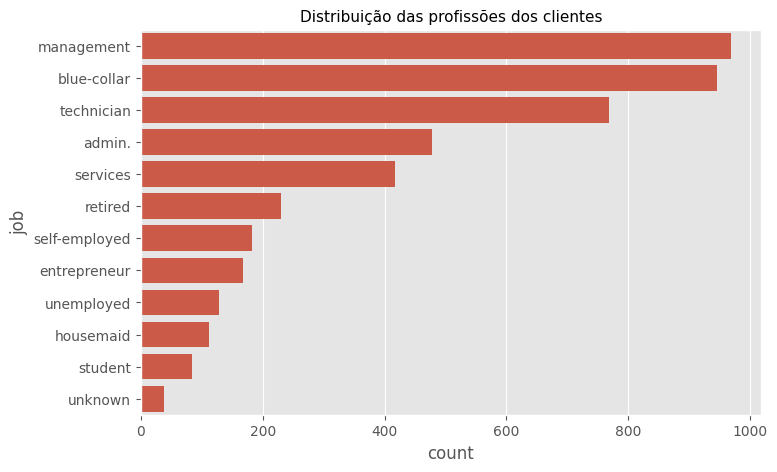

In [6]:
fig, ax = plt.subplots(figsize=(8,5))

ordem = df['job'].value_counts().sort_values(ascending=False).index

ax = sns.countplot(data=df, y='job', order=ordem, ax=ax)
ax.set_title('Distribuição das profissões dos clientes')

A análise do gráfico mostra que a profissão mais comum entre os clientes é **management**, seguida por **blue-collar** e **technician**.

Essas três categorias concentram a maior parte dos clientes presentes no dataset, indicando uma predominância de profissionais ligados a **cargos de gestão, trabalhos operacionais e atividades técnicas**.

Por outro lado, profissões como **student**, **housemaid**, **unemployed** e **unknown** aparecem com frequência significativamente menor na base de dados.

## Principais formas de contato com os clientes

Nesta etapa da análise exploratória, busca-se identificar **quais são as principais formas de contato utilizadas pela instituição financeira para se comunicar com os clientes**.

A variável **contact** representa o canal utilizado durante as campanhas de marketing, podendo assumir valores como **cellular**, **telephone** ou **unknown**.

Para compreender melhor essa distribuição, foram construídos dois gráficos:

- **Distribuição absoluta**, mostrando o número total de ocorrências de cada forma de contato.
- **Distribuição percentual**, permitindo visualizar a proporção que cada canal representa no conjunto de dados.

Essa análise ajuda a entender **quais canais de comunicação são mais utilizados pela instituição**.

In [7]:
percentual = df['contact'].value_counts(normalize = True) *100

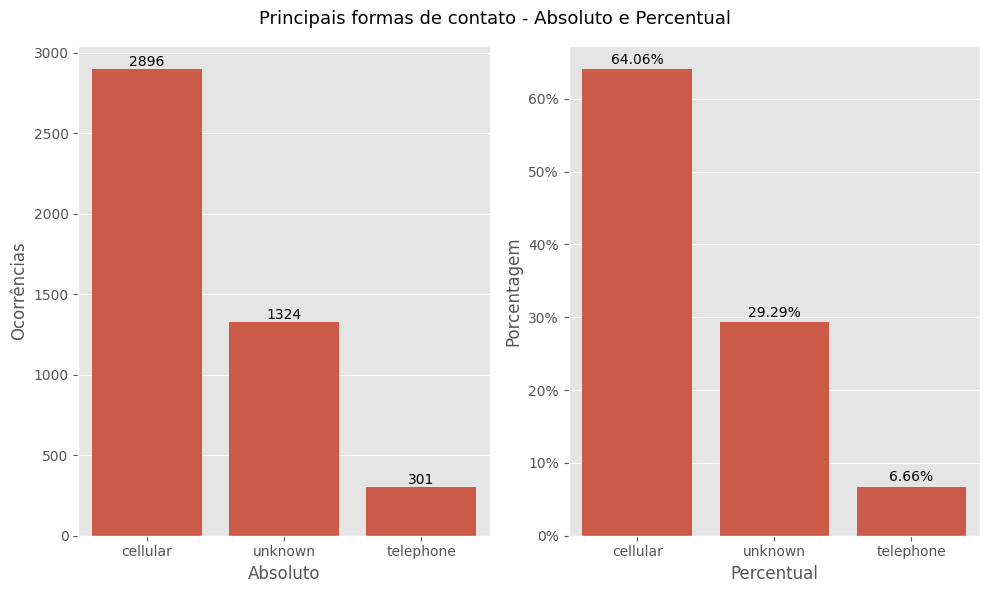

In [43]:
fig, axes = plt.subplots(1,2, figsize = (10, 6))

fig.suptitle('Principais formas de contato - Absoluto e Percentual')

axes[0] = sns.countplot(data = df, x = 'contact', ax = axes[0])
axes[0].bar_label(axes[0].containers[0])
axes[0].set_xlabel('Absoluto')
axes[0].set_ylabel('Ocorrências')

axes[1] = sns.barplot(x = percentual.index, y = percentual.values, ax = axes[1])
axes[1].bar_label(axes[1].containers[0], fmt = '%1.2f%%', padding = 2) # Padding afasta o numero da barra
axes[1].set_xlabel('Percentual')
axes[1].set_ylabel('Porcentagem')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
plt.tight_layout()
plt.show()


A partir da análise dos gráficos, observa-se que o **contato via celular é, de longe, o canal mais utilizado pela instituição**, representando aproximadamente **64% das interações** com os clientes.

Em seguida aparece a categoria **unknown**, que corresponde a cerca de **29% dos registros**, indicando casos em que o tipo de contato não foi identificado ou registrado no dataset.

Por outro lado, o **contato via telefone fixo (telephone)** é significativamente menos utilizado, representando apenas **cerca de 7% das interações**.

Esses resultados sugerem que a instituição financeira **prioriza o uso de dispositivos móveis para comunicação com os clientes**, o que reflete a tendência atual de digitalização e maior uso de celulares nas interações com serviços financeiros.

## Relação entre idade e saldo bancário

Nesta etapa da análise, busca-se investigar se existe alguma relação entre a **idade dos clientes** e o **saldo bancário (balance)**.

Como ambas são variáveis numéricas, utilizou-se um **gráfico de dispersão (scatterplot)** para analisar o comportamento conjunto dessas variáveis.

Esse tipo de visualização permite identificar possíveis padrões, tendências ou correlações entre os valores observados.

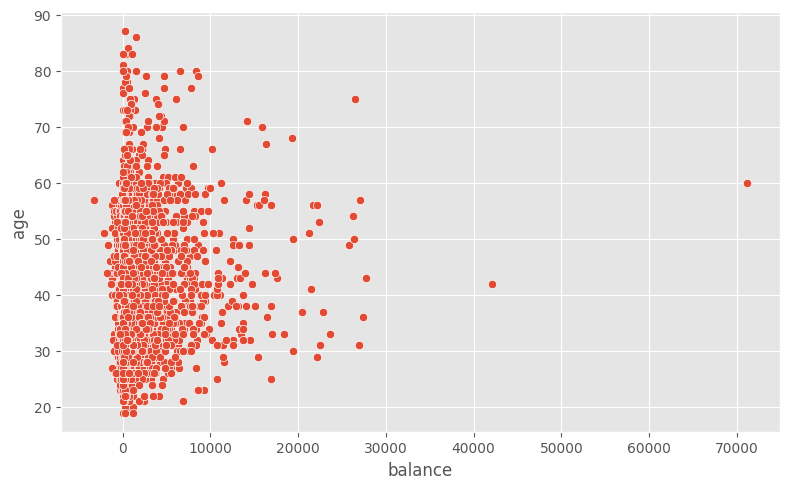

In [9]:
fig, ax = plt.subplots(figsize = (8, 5))

ax = sns.scatterplot(data = df, x = 'balance', y ='age')

plt.tight_layout()

A partir da visualização do gráfico, observa-se que **não há um padrão claro que indique uma relação entre idade e saldo bancário**. Os pontos encontram-se bastante dispersos ao longo do gráfico, sem a formação de uma tendência crescente ou decrescente.

Dessa forma, não se identifica uma relação evidente entre essas duas variáveis neste conjunto de dados, sugerindo que **a idade dos clientes não exerce influência direta sobre o saldo bancário**.

## Relação entre saldo bancário e características financeiras dos clientes

Nesta etapa, busca-se investigar se o **saldo bancário médio dos clientes (balance)** varia de acordo com três características financeiras relevantes:

- **default**: histórico de inadimplência
- **housing**: existência de financiamento imobiliário
- **loan**: existência de empréstimo pessoal

A análise será conduzida em duas etapas:

1. Comparação do **saldo médio entre os diferentes grupos**
2. Avaliação da **relação entre inadimplência, habitação e contratação de empréstimos**

Essa abordagem permite compreender possíveis padrões de comportamento financeiro entre os clientes.

In [10]:
media_default = df.groupby('default')['balance'].mean()
media_housing = df.groupby('housing')['balance'].mean()
media_loan = df.groupby('loan')['balance'].mean()

Text(0.5, 0, 'Empréstimo')

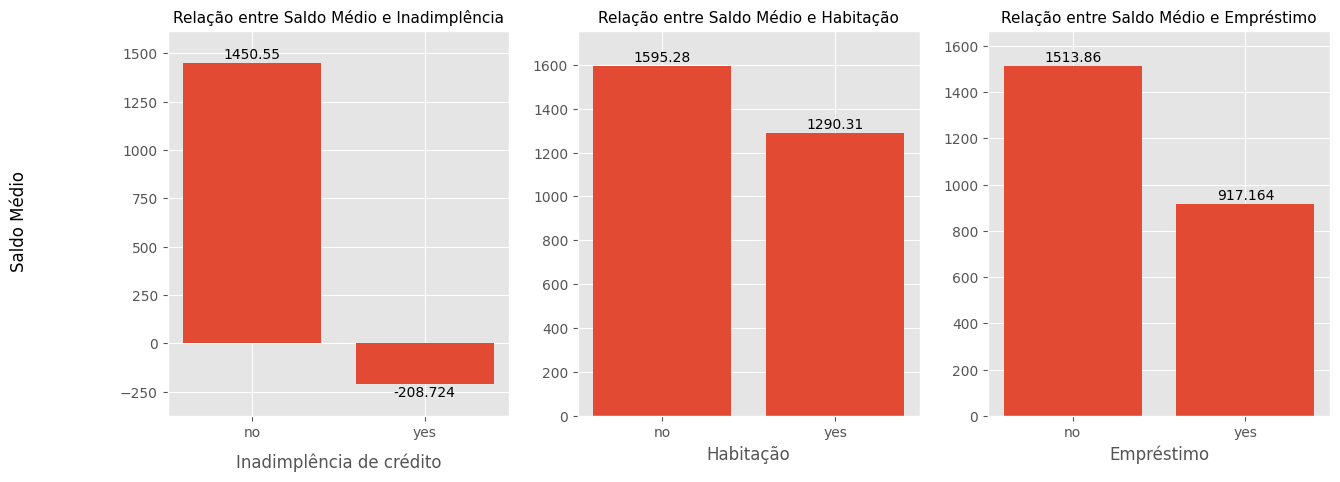

In [11]:
fig, axes = plt.subplots(1, 3, figsize = (15, 5))

fig.supylabel('Saldo Médio')
# Gráfico 1
axes[0].bar(media_default.index, media_default.values)
for container in axes[0].containers:
    axes[0].bar_label(container, label_type = 'edge', padding = 1)
axes[0].margins(y = 0.1)
axes[0].set_title('Relação entre Saldo Médio e Inadimplência')
axes[0].set_xlabel('Inadimplência de crédito', labelpad = 10)

#max_val = media_default.values.max()
# axes[0].set_ylim(0, max_val * 1.10)

# Gráfico 2
axes[1].bar(media_housing.index, media_housing.values)
for container in axes[1].containers:
    axes[1].bar_label(container, label_type = 'edge', padding = 1)
axes[1].margins(y = 0.1)
axes[1].set_title('Relação entre Saldo Médio e Habitação')
axes[1].set_xlabel('Habitação')

# Gráfico 3
axes[2].bar(media_loan.index, media_loan.values)
for container in axes[2].containers:
    axes[2].bar_label(container, label_type = 'edge', padding = 1)
axes[2].margins(y = 0.1)
axes[2].set_title('Relação entre Saldo Médio e Empréstimo')
axes[2].set_xlabel('Empréstimo')


Observa-se que clientes **sem histórico de inadimplência apresentam maior saldo médio**, indicando maior estabilidade financeira.

Além disso, clientes **sem financiamento imobiliário também demonstram saldo médio superior**, o que pode estar associado a menor comprometimento de renda com dívidas de longo prazo.

Por outro lado, a relação entre saldo médio e existência de empréstimos pessoais não apresenta diferença tão expressiva, sugerindo que a contratação desse tipo de crédito pode depender de outros fatores além do saldo disponível.

Diante desses resultados, torna-se relevante investigar se a combinação entre inadimplência e financiamento imobiliário influencia a **probabilidade de contratação de empréstimos pessoais**.

Text(0.5, 1.0, 'Propensão a Tomar Empréstimo')

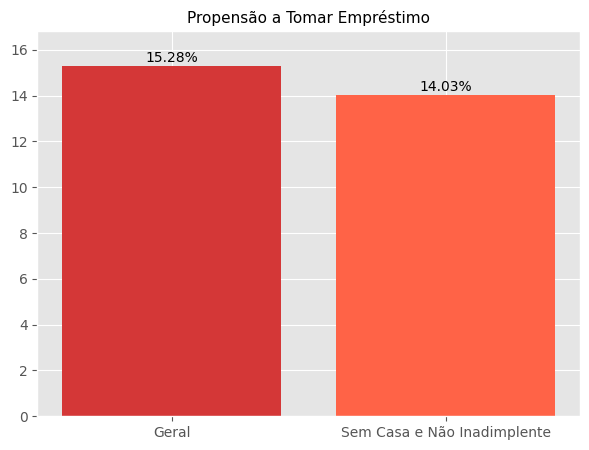

In [12]:
# Propensão geral
prop_geral = (df['loan'] == 'yes').mean() * 100

# Propensão do grupo específico
grupo = df[(df['housing'] == 'no') & (df['default'] == 'no')]
prop_grupo = (grupo['loan'] == 'yes').mean() * 100

# Construção gráfica
categorias = ['Geral', 'Sem Casa e Não Inadimplente']
valores = [prop_geral, prop_grupo]

fig, ax = plt.subplots(figsize = (7, 5))

ax.bar(categorias, valores, color=["#D43737", '#FF6347'])
for container in ax.containers:
    ax.bar_label(container, fmt = '%1.2f%%', padding = 1)
ax.margins(y = 0.1)

ax.set_title('Propensão a Tomar Empréstimo')


A análise comparativa entre a propensão geral à contratação de empréstimos e a propensão observada no grupo de clientes sem financiamento imobiliário e sem histórico de inadimplência permite avaliar o comportamento financeiro desse segmento específico.

Caso a propensão do grupo seja inferior à média geral, isso sugere que clientes com maior estabilidade financeira tendem a recorrer menos a empréstimos pessoais, possivelmente devido a menor necessidade de crédito de curto prazo.

Por outro lado, se a propensão for superior, isso pode indicar maior acesso ou confiança no sistema de crédito por parte desse grupo.

Essa análise contribui para compreender como diferentes perfis financeiros influenciam a demanda por crédito.

In [13]:
loan_statistic = pd.crosstab([df['default'], df['housing']], df['loan'], normalize='index') * 100
loan_statistic = (loan_statistic
                  .rename(columns={'no': 'NÃO', 'yes': 'SIM'})
                  .rename_axis(columns='Empréstimo')
                  .rename(index={'no': 'Não Inadimplente', 'yes': 'Inadimplente'}, level='default')
                  .rename(index={'no': 'Sem Casa', 'yes': 'Com Casa'}, level='housing')
                  .rename_axis(index ={'default': 'Inadimplência', 'housing': ' Casa'}))
loan_statistic.style.format('{:.2f}%')

A análise conjunta entre inadimplência e financiamento imobiliário revela diferenças relevantes na propensão à contratação de empréstimos.

Clientes **inadimplentes e sem financiamento imobiliário apresentam a maior taxa de contratação de empréstimos (45,16%)**, indicando possível maior dependência de crédito de curto prazo.

Por outro lado, clientes **não inadimplentes apresentam menor propensão à contratação de empréstimos**, independentemente da posse de financiamento imobiliário, sugerindo comportamento financeiro mais conservador.

Além disso, clientes com financiamento imobiliário tendem a apresentar menor contratação adicional de empréstimos, possivelmente devido ao maior comprometimento da renda com dívidas já existentes.

Esses resultados indicam que o histórico de inadimplência parece ser um fator mais determinante para a contratação de novos empréstimos do que a existência de financiamento imobiliário.

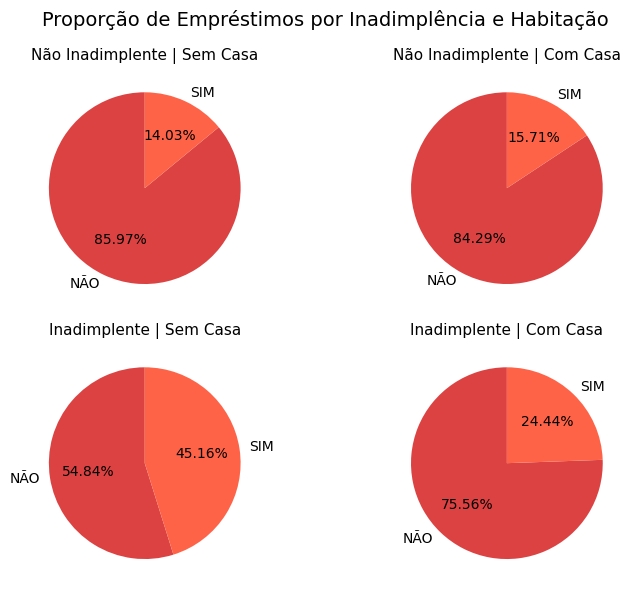

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(8,6))

situacoes = loan_statistic.index

for ax, situacao in zip(axes.flatten(), situacoes):
    
    valores = loan_statistic.loc[situacao]
    
    wedges, texts, autotexts = ax.pie(
        valores,
        labels=valores.index,
        autopct='%1.2f%%',
        startangle=90,
        colors=["#DC4242", '#FF6347']
    )

    for t in texts:
        t.set_fontsize(10)

    for t in autotexts:
        t.set_fontsize(10)

    ax.set_title(f'{situacao[0]} | {situacao[1]}')

plt.suptitle('Proporção de Empréstimos por Inadimplência e Habitação', fontsize=14)

plt.tight_layout()
plt.show()

A visualização gráfica reforça os padrões identificados anteriormente, evidenciando que a **inadimplência exerce maior influência sobre a contratação de empréstimos do que a existência de financiamento imobiliário**.

Clientes inadimplentes demonstram comportamento mais intensivo no uso de crédito, especialmente quando não possuem financiamento habitacional, o que pode indicar maior vulnerabilidade financeira ou maior dependência de crédito rotativo.

Esses achados são relevantes para estratégias de concessão de crédito, pois sugerem que o histórico de inadimplência pode ser um indicador mais crítico de risco e comportamento financeiro do que o comprometimento com financiamentos de longo prazo.

## Análise de Outliers na Variável Saldo Bancário

Nesta etapa, o objetivo é identificar clientes com valores extremos na variável **saldo bancário (balance)** utilizando o método do **Intervalo Interquartil (IQR)**.

A partir dessa identificação, busca-se investigar:

- Se a proporção de contratação do depósito a prazo difere entre **outliers e não-outliers**
- Se existem diferenças na **idade média e distribuição etária**
- Se o comportamento do **saldo médio e sua distribuição** variam entre os grupos
- Se há algum **padrão temporal na ocorrência dos outliers ao longo dos meses**

Essa análise permite compreender se clientes com comportamento financeiro atípico apresentam características comerciais ou demográficas distintas.

In [15]:
q1 = df['balance'].quantile(0.25)
q3 = df['balance'].quantile(0.75)

iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

df['outlier_balance'] = (df['balance'] < lim_inf) | (df['balance'] > lim_sup)
df['outlier_balance'] = df['outlier_balance'].map({False: 'Não Outlier', True: 'Outlier'})

### Conversão em Depósito a Prazo entre Outliers e Não-Outliers

Nesta etapa, analisamos se clientes classificados como outliers apresentam comportamento distinto na contratação do depósito a prazo em comparação com clientes dentro do padrão esperado.

In [16]:
outlier_y= df.groupby('outlier_balance')['y'].value_counts(normalize=True) * 100

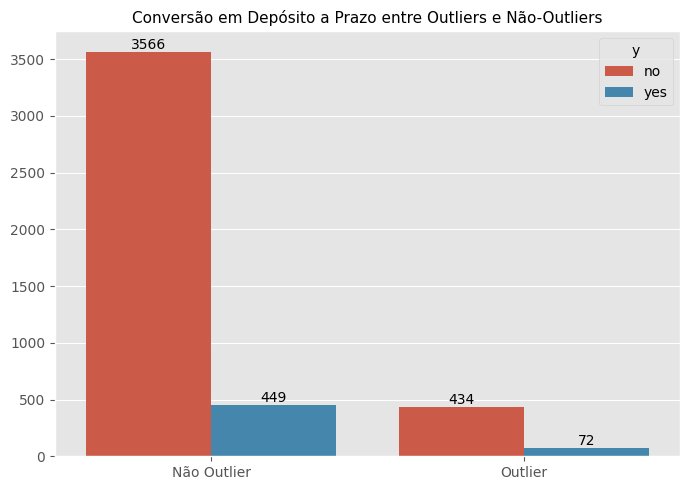

In [17]:
fig, ax = plt.subplots(figsize =(7, 5))
ax = sns.countplot(data = df, x  = 'outlier_balance', hue = 'y')

for container in ax.containers:
    ax.bar_label(container)


ax.set_title('Conversão em Depósito a Prazo entre Outliers e Não-Outliers')
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

### Comparação da Idade entre Outliers e Não-Outliers

Agora investigamos se clientes com saldos extremos apresentam diferenças na idade média ou na distribuição etária em relação aos demais clientes.

In [18]:
outlier_age = df.groupby('outlier_balance')['age'].mean()
outlier_age


outlier_balance
Não Outlier    40.898630
Outlier        43.324111
Name: age, dtype: float64

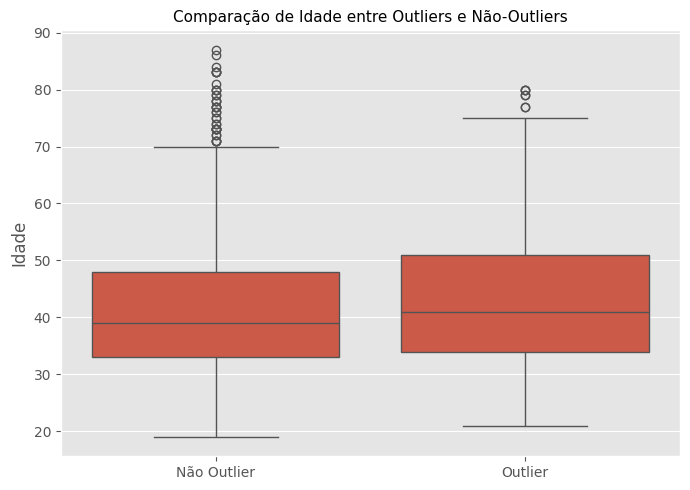

In [19]:
fig, ax = plt.subplots(figsize =(7, 5))
ax = sns.boxplot(data = df, x = 'outlier_balance', y='age')
ax.set_title('Comparação de Idade entre Outliers e Não-Outliers')
ax.set_xlabel('')
ax.set_ylabel('Idade')

plt.tight_layout()
plt.show()

### Comparação do Saldo Médio entre Outliers e Não-Outliers

Aqui avaliamos se a presença de outliers influencia significativamente a média do saldo bancário, além de observar a dispersão dessa variável.

In [20]:
outlier_balance_mean = df.groupby('outlier_balance')['balance'].mean()
outlier_balance_mean

outlier_balance
Não Outlier     645.734496
Outlier        7587.375494
Name: balance, dtype: float64

### Distribuição do Saldo Bancário

A análise visual da distribuição permite identificar a intensidade da variabilidade dos saldos entre os grupos e a presença de assimetrias ou dispersões relevantes.distribuição

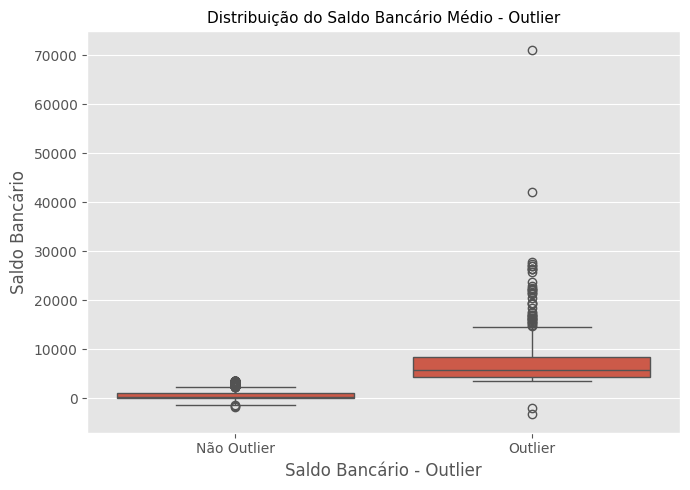

In [21]:
fig, ax = plt.subplots(figsize =(7, 5))
ax = sns.boxplot(data = df, x = 'outlier_balance', y='balance')
ax.set_title('Distribuição do Saldo Bancário Médio - Outlier')
ax.set_xlabel('Saldo Bancário - Outlier')
ax.set_ylabel('Saldo Bancário')

plt.tight_layout()
plt.show()

### Distribuição Temporal dos Outliers

Por fim, analisamos como os outliers estão distribuídos ao longo dos meses, buscando identificar possíveis padrões sazonais ou períodos de maior incidência.

In [22]:
outliers = df[df['outlier_balance'] == 'Outlier']
nao_outilers = df[df['outlier_balance'] == 'Não Outlier']

#### Distribuição percentual mensal dos Outliers

In [23]:
# Definir ordem cronológica dos meses
ordem_meses = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

outliers_month = (outliers['month']
                  .value_counts(normalize = True)
                  .mul(100)
                  .reindex(ordem_meses)
)

outliers_month

month
jan     1.976285
feb     3.557312
mar     2.173913
apr     7.509881
may    23.913043
jun    14.426877
jul     7.707510
aug    14.031621
sep     0.988142
oct     2.766798
nov    19.762846
dec     1.185771
Name: proportion, dtype: float64

#### Distribuição percentual mensal dos Não-Outliers

In [24]:
nao_outliers_month = (nao_outilers['month']
                  .value_counts(normalize=True) 
                  .mul(100)
                  .reindex(ordem_meses))
nao_outliers_month 


month
jan     3.437111
feb     5.080946
mar     0.946451
apr     6.351183
may    31.805729
jun    11.407223
jul    16.612702
aug    13.997509
sep     1.170610
oct     1.643836
nov     7.198007
dec     0.348692
Name: proportion, dtype: float64

### Visualização da Distribuição Mensal dos Outliers

O gráfico a seguir ilustra a concentração percentual dos clientes classificados como outliers ao longo dos meses.

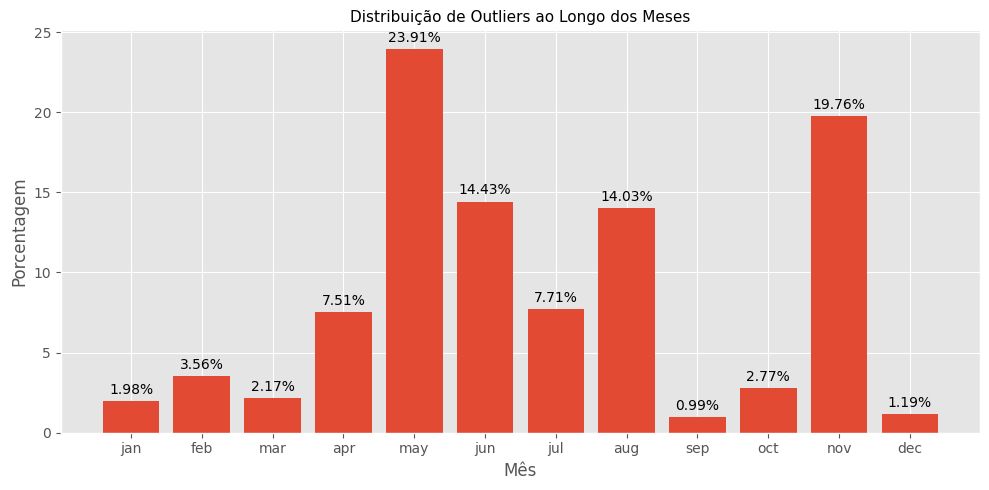

In [25]:
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(outliers_month.index, outliers_month.values)

for container in ax.containers:
    ax.bar_label(container, fmt='%1.2f%%', padding=3)

ax.set_title('Distribuição de Outliers ao Longo dos Meses')
ax.set_xlabel('Mês')
ax.set_ylabel('Porcentagem')

plt.tight_layout()

### Insight sobre a Distribuição Temporal dos Outliers

A análise da distribuição mensal dos clientes classificados como outliers indica que não há uma concentração extremamente elevada em um único período específico, sugerindo que a ocorrência de saldos extremos não está fortemente associada a sazonalidade.

Entretanto, pequenas variações entre os meses podem indicar mudanças pontuais no comportamento financeiro dos clientes ou estratégias específicas de contato adotadas pela instituição em determinados períodos.

De forma geral, a distribuição relativamente homogênea sugere que os outliers representam um perfil estrutural dentro da base de clientes, e não um fenômeno isolado no tempo.

## Análise de Correlação Linear entre Variáveis Numéricas

Nesta etapa, busca-se identificar o grau de relacionamento linear entre as variáveis numéricas presentes na base de dados, utilizando o **coeficiente de correlação de Pearson**.

A análise de correlação permite:

- Identificar variáveis que se movimentam juntas
- Detectar possíveis relações redundantes
- Auxiliar na seleção de variáveis para modelagem preditiva
- Compreender padrões estruturais do comportamento dos clientes

Valores próximos de:

- **+1** → forte correlação positiva
- **−1** → forte correlação negativa
- **0** → ausência de correlação linear

In [26]:
numericas = df.select_dtypes(include = 'number')
corr = numericas.corr(method = 'pearson')
corr

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.083820,-0.017853,-0.002367,-0.005148,-0.008894,-0.003511
balance,0.083820,1.000000,-0.008677,-0.015950,-0.009976,0.009437,0.026196
day,-0.017853,-0.008677,1.000000,-0.024629,0.160706,-0.094352,-0.059114
duration,-0.002367,-0.015950,-0.024629,1.000000,-0.068382,0.010380,0.018080
campaign,-0.005148,-0.009976,0.160706,-0.068382,1.000000,-0.093137,-0.067833
pdays,-0.008894,0.009437,-0.094352,0.010380,-0.093137,1.000000,0.577562
previous,-0.003511,0.026196,-0.059114,0.018080,-0.067833,0.577562,1.000000


Para facilitar a interpretação visual das relações lineares, utiliza-se um **mapa de calor (heatmap)**, onde cores mais intensas indicam maior magnitude de correlação entre as variáveis.

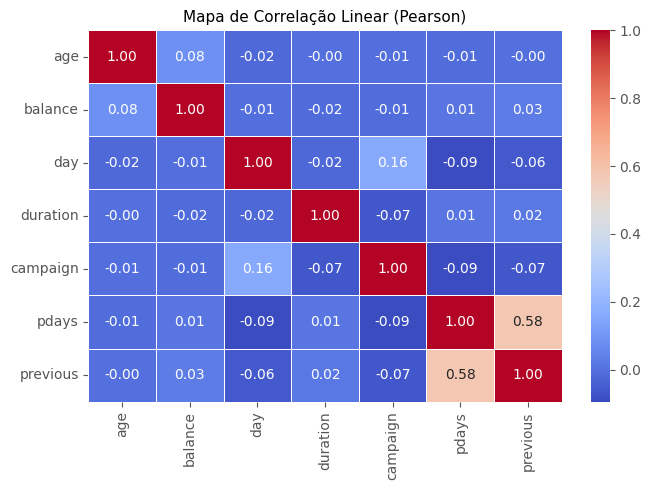

In [27]:
fig, ax = plt.subplots(figsize = (7, 5))
ax = sns.heatmap(
    corr,
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm',
    linewidths = 0.5
)

ax.set_title('Mapa de Correlação Linear (Pearson)')
plt.tight_layout()
plt.show()

### Principais Insights da Análise de Correlação

A análise do mapa de calor evidencia que a maioria das variáveis apresenta **baixa correlação linear entre si**, indicando relativa independência nos comportamentos analisados.

Esse resultado é esperado em bases de dados bancárias, onde fatores financeiros, demográficos e operacionais tendem a influenciar os clientes de forma multifatorial.

A ausência de correlações muito elevadas é positiva para etapas posteriores de modelagem preditiva, pois reduz o risco de **multicolinearidade**, contribuindo para modelos mais estáveis e interpretáveis.

## Análise Multivariada da Conversão em Depósito a Prazo

Nesta etapa, busca-se compreender como a **taxa de conversão do depósito a prazo (y)** varia em função de duas variáveis categóricas:

- **loan** → se o cliente possui empréstimo pessoal
- **education** → nível de escolaridade do cliente

A análise conjunta dessas variáveis permite identificar possíveis **padrões de comportamento comercial**, auxiliando na segmentação de clientes e na definição de estratégias de abordagem mais eficientes.

Para isso, calcula-se a **taxa média de conversão (%)** para cada combinação entre nível de escolaridade e situação de empréstimo.

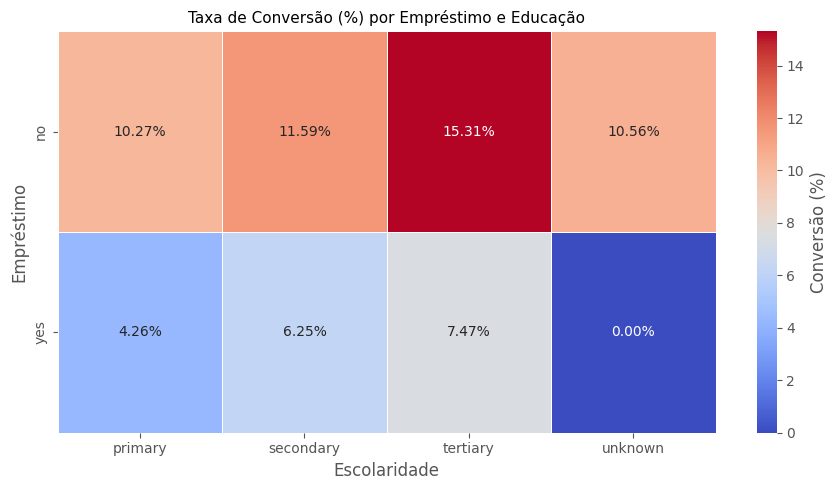

In [28]:
# Criando a tabela de conversão (%)
heatmap_data = pd.crosstab( 
    df['loan'],
    df['education'],
    values = (df['y'] == 'yes'),
    aggfunc = 'mean'
) * 100

# Plotando gráfico heatmap
fig, ax = plt.subplots(figsize = (9, 5))

ax = sns.heatmap(
    heatmap_data,
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm',
    linewidths= 0.5,
    cbar_kws={'label': 'Conversão (%)'},
    ax=ax
)
# adicionar % manualmente 
for t in ax.texts:
    t.set_text(t.get_text() + '%')

ax.set_title('Taxa de Conversão (%) por Empréstimo e Educação')
ax.set_xlabel('Escolaridade')
ax.set_ylabel('Empréstimo')

plt.tight_layout()
plt.show()


### Insights da Análise Multivariada

Observa-se que a taxa de conversão do depósito a prazo varia de forma relevante conforme o nível de escolaridade e a existência de empréstimos pessoais.

De modo geral, clientes com maior nível educacional tendem a apresentar **maior propensão à contratação**, possivelmente devido a maior compreensão dos produtos financeiros ou maior estabilidade econômica.

Além disso, a presença de empréstimos pode alterar esse comportamento, indicando que o **endividamento prévio influencia a decisão de contratação**, seja por restrição financeira ou por maior relacionamento com a instituição.

Essa análise evidencia a importância de considerar múltiplas características simultaneamente na definição de estratégias comerciais, permitindo abordagens mais direcionadas e eficientes.

## Probabilidade Condicional de Conversão em Depósito a Prazo

Nesta etapa, o objetivo é calcular a **probabilidade de um cliente contratar o depósito a prazo, dado que ele já foi contatado anteriormente pela instituição**.

Esse tipo de análise é conhecido como **probabilidade condicional**, pois avalia a chance de ocorrência de um evento considerando que outra condição já foi satisfeita.

No contexto bancário, essa análise permite entender se **contatos prévios aumentam a efetividade das campanhas comerciais**, auxiliando na otimização de estratégias de relacionamento com clientes.

In [29]:
# Clientes ja contatados antes
contatados = df[df['previous'] > 0]
prob_condicional = (contatados['y'] == 'yes').mean() *100
prob_condicional
#print(f'Probabilidade de conversão dado contato prévio: {prob_condicional:.2f}%')

np.float64(22.54901960784314)

### Insight sobre a Probabilidade Condicional

O resultado indica a taxa de conversão entre clientes que já haviam sido contatados anteriormente, permitindo avaliar a efetividade de abordagens sucessivas.

Caso essa probabilidade seja superior à taxa média geral de conversão, isso sugere que **interações prévias aumentam a propensão à contratação**, possivelmente devido ao fortalecimento do relacionamento ou maior familiaridade com o produto.

Por outro lado, se a taxa for semelhante ou inferior, pode indicar **saturação de contato ou baixa efetividade das abordagens anteriores**, sinalizando a necessidade de revisão nas estratégias comerciais adotadas.